In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from src.algos.esprit import esprit_cosine
from src.algos.power_law import power_law
from src.algos.glsae import glsae
from src.algos.gdmae import gdmae
import json

rng = np.random.default_rng()

In [ ]:
target = 1/3.0

In [ ]:
with open('./output/comparison/esprit.jsonl', 'w') as f:
    for j in range(100):
        res = [esprit_cosine(target, i, 20, rng) for i in 2 ** np.arange(1, 10)]
        y, x, z = zip(*res)
        json.dump({"query": np.array(x).tolist(),"value": np.array(y).tolist(), "depth": np.array(z).tolist()}, f)
        f.write("\n")

In [ ]:
with open('./output/comparison/gdmae.jsonl', 'w') as f:
    for j in range(100):
        res = [gdmae(target, i, i * 20, rng, sine=True) for i in 2 ** np.arange(0, 16)]
        y, x, z = zip(*res)
        json.dump({"query": np.array(x).tolist(),"value": np.array(y).tolist(), "depth": np.array(z).tolist()}, f)
        f.write("\n")

In [ ]:
#plt.rcParams.update({'font.size': 15, 'font.family': "serif","font.serif": "CMU Serif", 'text.usetex': True})

In [ ]:
algos = ["QPE", "ChebAE", "CSAE", "ESPRIT", "Sensing", "GDMAE*", "GLSAE"]
linestyle_tuple = [
     ('dotted',                (0, (1, 2))),
     ('densely dotted',        (0, (1, 1))),
     ('dashed',                (0, (5, 3))),
     ('densely dashed',        (0, (3, 1))),
     ('dashdotted',            (0, (3, 2, 1, 2))),
     ('densely dashdotted',    (0, (3, 1, 1, 1))),
     ('solid', 'solid')]

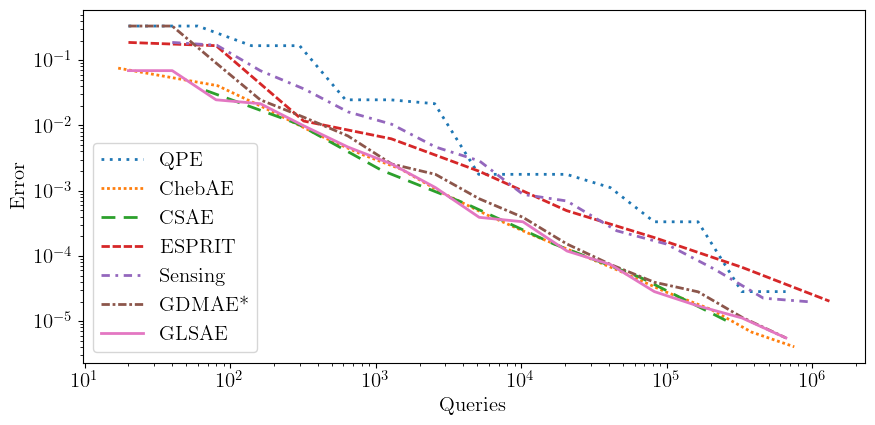

In [23]:
fig, ax = plt.subplots(figsize=(9,4.5))
for algo, (_,style) in zip(algos,linestyle_tuple):
    with open(f'./output/comparison/{algo.lower()}.jsonl', 'r') as json_file:
        json_list = list(json_file)
    time = []
    value = []
    for json_str in json_list:
        res = json.loads(json_str)
        time.append(res["query"])
        value.append(res["value"])
    time = np.max(time,axis=0)
    error = np.median(np.abs(np.array(value)-target), axis=0)
    plt.plot(time,error,label=algo,linestyle=style,linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Queries")
plt.ylabel("Error")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("compare_query.pdf", bbox_inches='tight')

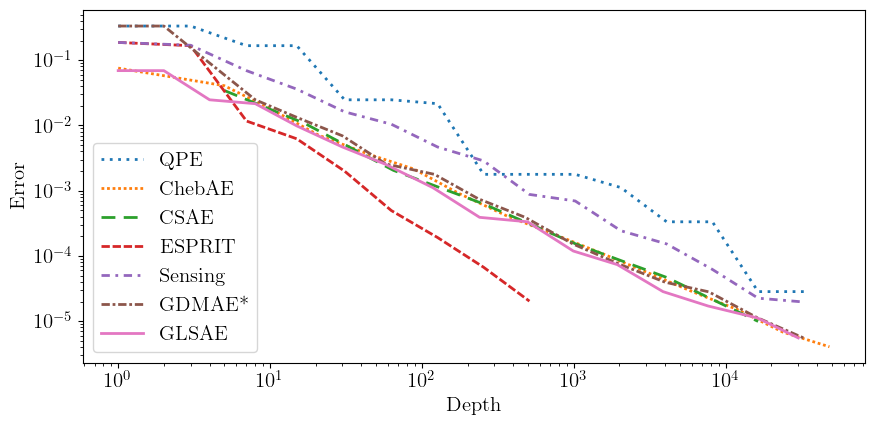

In [24]:
fig, ax = plt.subplots(figsize=(9,4.5))
for algo, (_,style) in zip(algos,linestyle_tuple):
    with open(f'./output/comparison/{algo.lower()}.jsonl', 'r') as json_file:
        json_list = list(json_file)
    time = []
    value = []
    for json_str in json_list:
        res = json.loads(json_str)
        time.append(res["depth"])
        value.append(res["value"])
    time = np.max(time,axis=0)
    error = np.median(np.abs(np.array(value)-target), axis=0)
    plt.plot(time,error,label=algo,linestyle=style,linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Depth")
plt.ylabel("Error")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("compare_depth.pdf", bbox_inches='tight')